# Machine Learning 2 - Neural Networks

In this lab, we will use simple Neural Networks to classify the images from the simplified CIFAR-10 dataset. We will compare our results with those obtained with Decision Trees and Random Forests.

Lab objectives
----
* Classification with neural networks
* Influence of hidden layers and of the selected features on the classifier results

In [1]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image
        
dataset = CIFAR10('./CIFAR10')


Pre-loading training data
Pre-loading test data


We will use the *[Multi-Layer Perceptron](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)* implementation from scikit-learn, which is only available since version 0.18. You can check which version of scikit-learn is installed by executing this :

In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


If you have version 0.17 or older, please update your scikit-learn installation (for instance, with the command *pip install scikit-learn==0.19.1* in the terminal or Anaconda prompt)

## Build a simple neural network

* Using the [MLPClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) from scikit-learn, create a neural network with a single hidden layer.
* Train this network on the CIFAR dataset.
* Using cross-validation, try to find the best possible parameters.

In [3]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_train = dataset.train['hog']
y_train = dataset.train['labels']
X_test = dataset.test['hog']
y_test = dataset.test['labels']

hidden_sizes = [20, 50, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_size = None

print("Cross-validation results:")
for size in hidden_sizes:
    clf = MLPClassifier(hidden_layer_sizes=(size,), max_iter=300, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    mean_score = scores.mean()
    print(f"hidden_layer_sizes = ({size},) -> mean CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_size = size

print("\nBest hidden layer size:", best_size)
print("Best CV accuracy:", best_score)

best_clf = MLPClassifier(hidden_layer_sizes=(best_size,), max_iter=300, random_state=42)
best_clf.fit(X_train, y_train)
print("Test accuracy:", best_clf.score(X_test, y_test))


Cross-validation results:


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn

hidden_layer_sizes = (20,) -> mean CV accuracy = 0.7642


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn

hidden_layer_sizes = (50,) -> mean CV accuracy = 0.7819


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn

hidden_layer_sizes = (100,) -> mean CV accuracy = 0.7951

Best hidden layer size: 100
Best CV accuracy: 0.7951333333333334
Test accuracy: 0.8063333333333333


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [4]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(5)

for train,test in kf.split(dataset.train['hog'], dataset.train['labels']):
    train_x = dataset.train['hog'][train]
    train_y = dataset.train['labels'][train]
    
    test_x = dataset.train['hog'][test]
    test_y = dataset.train['labels'][test]

## Add hidden layers to the network.

Try to change the structure of the network by adding hidden layers. Using cross-validation, try to find the best architecture for your network.

In [5]:

architectures = [(50, 50), (100, 50), (100, 100)]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_architecture = None

print("Cross-validation results:")
for architecture in architectures:
    clf = MLPClassifier(hidden_layer_sizes=architecture, max_iter=300, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    mean_score = scores.mean()
    print(f"hidden_layer_sizes = {architecture} -> mean CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_architecture = architecture

print("\nBest architecture:", best_architecture)
print("Best CV accuracy:", best_score)

best_clf = MLPClassifier(hidden_layer_sizes=best_architecture, max_iter=300, random_state=42)
best_clf.fit(X_train, y_train)
print("Test accuracy:", best_clf.score(X_test, y_test))


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Cross-validation results:


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn

hidden_layer_sizes = (50, 50) -> mean CV accuracy = 0.7672


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn

hidden_layer_sizes = (100, 50) -> mean CV accuracy = 0.7687


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a

hidden_layer_sizes = (100, 100) -> mean CV accuracy = 0.7777

Best architecture: (100, 100)
Best CV accuracy: 0.7777333333333333
Test accuracy: 0.772


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


---

# Explication détaillée du notebook — Préparation à la défense orale

## 1. Objectif global du laboratoire

Ce notebook a pour but de **classifier les images du dataset CIFAR-10 simplifié** à l'aide de **réseaux de neurones (Multi-Layer Perceptron, MLP)**, puis de comparer ces résultats avec ceux obtenus précédemment avec des arbres de décision et des forêts aléatoires (Lab ML1).

Deux questions principales sont étudiées :
1. **Quel est l'effet du nombre de neurones dans une couche cachée unique ?**
2. **Quel est l'effet de l'ajout de couches cachées supplémentaires (réseau plus profond) ?**

---

## 2. Théorie : le Multi-Layer Perceptron (MLP)

### 2.1. Définition d'un perceptron
Un **perceptron** est l'unité de base d'un réseau de neurones. Il calcule :

$$ y = \varphi\!\left( \sum_{i=1}^{n} w_i x_i + b \right) $$

où :
- $x_i$ sont les entrées (features),
- $w_i$ les poids synaptiques (paramètres appris),
- $b$ le biais,
- $\varphi$ la **fonction d'activation** (ReLU, sigmoïde, tanh…).

### 2.2. Le MLP
Un MLP est un empilement de couches de perceptrons :
- **Couche d'entrée** : reçoit les features (ici, le vecteur HOG).
- **Couches cachées** : apprennent des représentations intermédiaires non-linéaires.
- **Couche de sortie** : produit la prédiction (ici, 10 classes via softmax).

L'ajout de couches cachées permet au réseau d'apprendre des **fonctions plus complexes et non linéaires** (théorème d'approximation universelle).

### 2.3. Apprentissage : rétropropagation
Le réseau apprend par **descente de gradient stochastique** :
1. **Forward pass** : on propage l'entrée à travers les couches pour obtenir la prédiction.
2. **Calcul de la perte** : ici, **cross-entropy** entre la prédiction et le vrai label.
3. **Backward pass (backpropagation)** : on calcule le gradient de la perte par rapport à chaque poids via la règle de la chaîne.
4. **Mise à jour** : $w \leftarrow w - \eta \, \nabla_w \mathcal{L}$ (où $\eta$ est le taux d'apprentissage).

Par défaut, `MLPClassifier` de scikit-learn utilise l'optimiseur **Adam**, une variante de la descente de gradient avec moments adaptatifs.

### 2.4. Fonction d'activation (par défaut : ReLU)
$$ \mathrm{ReLU}(z) = \max(0, z) $$
Avantages : non saturante (évite le *vanishing gradient*), simple à calculer, sparsité naturelle.

### 2.5. Couche de sortie : softmax
Pour la classification multi-classes, la couche de sortie applique :
$$ p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}} $$
Cela transforme les logits en **distribution de probabilité** sur les 10 classes.

---

## 3. Le dataset et les features

### 3.1. CIFAR-10 simplifié
- 10 classes d'images (avion, voiture, oiseau, chat, etc.).
- Images 32×32 en couleur.
- Le module `lab_tools` fournit une version pré-chargée avec features déjà extraites.

### 3.2. Pourquoi les features HOG ?
On n'utilise **pas les pixels bruts** mais les **HOG (Histogram of Oriented Gradients)**.

**Principe du HOG** :
1. Calcul du gradient (magnitude et orientation) en chaque pixel.
2. Découpage de l'image en cellules.
3. Pour chaque cellule, construction d'un **histogramme des orientations** des gradients.
4. Normalisation par blocs pour la robustesse aux variations d'illumination.

**Pourquoi c'est important** :
- Les HOG capturent la **structure des contours et des formes**, qui sont discriminantes pour la reconnaissance d'objets.
- Le vecteur HOG est de taille fixe et **plus compact** que les pixels bruts → un MLP classique fonctionne mieux qu'avec des pixels (un CNN aurait été nécessaire pour exploiter les pixels bruts).
- Cela illustre le concept clé : **la qualité des features influence fortement les performances** du classifieur.

---

## 4. Explication détaillée du code

### 4.1. Chargement (cell 1)
```python
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image
dataset = CIFAR10('./CIFAR10')
```
Charge le dataset et pré-calcule les features HOG pour les ensembles train et test.

### 4.2. Première expérience : une seule couche cachée (cell 6)

```python
X_train = dataset.train['hog']
y_train = dataset.train['labels']
hidden_sizes = [20, 50, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```
- On extrait les features HOG et les labels.
- On teste **3 tailles de couche cachée** : 20, 50, 100 neurones.
- On utilise une **validation croisée stratifiée à 5 plis** :
  - *Stratifiée* = chaque pli conserve la même proportion de classes que le dataset complet (essentiel pour la classification).
  - *5-fold* = on entraîne 5 fois, chaque fois sur 4/5 des données et on évalue sur le 1/5 restant.
  - Cela donne une estimation robuste de la performance, indépendante d'un découpage particulier.

```python
clf = MLPClassifier(hidden_layer_sizes=(size,), max_iter=300, random_state=42)
scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
```
- `hidden_layer_sizes=(size,)` : **un tuple à un seul élément** = une seule couche cachée.
- `max_iter=300` : nombre maximum d'époques d'entraînement.
- `random_state=42` : reproductibilité (initialisation des poids et mélange).
- `cross_val_score` retourne un tableau de 5 accuracies (une par pli).

**On sélectionne la meilleure taille** (celle avec la moyenne CV la plus élevée), on **ré-entraîne sur tout le train**, puis on évalue sur le **test set** (jamais vu pendant la sélection de modèle).

### 4.3. Deuxième expérience : plusieurs couches cachées (cell 9)

```python
architectures = [(50, 50), (100, 50), (100, 100)]
```
- `(50, 50)` = 2 couches cachées de 50 neurones chacune.
- `(100, 50)` = 100 neurones puis 50 (architecture en entonnoir).
- `(100, 100)` = 2 couches de 100 neurones (plus de capacité).

Le reste du code est identique : CV stratifiée, sélection de la meilleure architecture, évaluation finale sur test.

### 4.4. Pourquoi un `StratifiedKFold` séparé en cell 7 ?
La cell 7 montre **manuellement** comment on découperait les données en train/validation pour chaque pli — c'est juste pédagogique pour comprendre ce que fait `cross_val_score` en interne.

---

## 5. Concepts clés à maîtriser pour la défense

### 5.1. Pourquoi la cross-validation ?
- Évite le **biais de sélection** : on ne se base pas sur un seul découpage train/val.
- Permet de **comparer équitablement** plusieurs hyperparamètres.
- Le **test set** reste intouché jusqu'à la fin pour donner une estimation **non biaisée** de la performance finale.

### 5.2. Risque d'overfitting
Quand on augmente la taille du réseau (plus de neurones, plus de couches) :
- ↑ capacité du modèle → peut apprendre des relations plus complexes.
- ↑ risque d'overfitting (apprend le bruit du train).
- Symptôme : accuracy train élevée mais accuracy CV/test faible.
- Régularisation possible : `alpha` (L2) dans `MLPClassifier`, early stopping, dropout (non disponible ici).

### 5.3. Comparaison avec arbres / random forests (Lab ML1)
- **Arbres de décision** : interprétables mais peu performants seuls, frontières axes-alignées.
- **Random Forests** : ensemble d'arbres, meilleure généralisation, robuste mais boîte noire.
- **MLP** : peut capturer des frontières non linéaires complexes, mais nécessite plus de tuning et de données.

### 5.4. Limites du MLP sur images
- Un MLP traite l'entrée comme un **vecteur plat** : il **ignore la structure spatiale 2D**.
- C'est pour cela qu'on utilise les HOG (qui encodent déjà la structure locale).
- Pour des pixels bruts, un **CNN** serait bien plus adapté (partage de poids, invariance à la translation).

### 5.5. Hyperparamètres importants du `MLPClassifier`
- `hidden_layer_sizes` : architecture du réseau.
- `activation` : `relu` (défaut), `tanh`, `logistic`.
- `solver` : `adam` (défaut, bon pour grands datasets), `lbfgs` (mieux pour petits datasets), `sgd`.
- `alpha` : terme de régularisation L2 sur les poids.
- `learning_rate_init` : taux d'apprentissage initial.
- `max_iter` : nombre maximum d'époques.
- `random_state` : graine pour la reproductibilité.

---

## 6. Questions probables en défense

**Q : Pourquoi normaliser les features avant un MLP ?**
R : Les MLP sont sensibles à l'échelle car la descente de gradient converge mal si certaines features dominent. Les HOG sont déjà normalisés par blocs, ce qui aide.

**Q : Que se passe-t-il si on enlève toutes les couches cachées ?**
R : On obtient une **régression logistique multinomiale** (modèle linéaire) — incapable d'apprendre des frontières non linéaires.

**Q : Pourquoi `StratifiedKFold` plutôt que `KFold` ?**
R : Pour garantir que chaque pli ait la même distribution de classes, surtout si certaines classes sont rares — sinon un pli pourrait ne contenir aucun exemple d'une classe.

**Q : Comment interpréter une grande différence entre accuracy CV et accuracy test ?**
R : Soit le test set a une distribution différente, soit on a sur-optimisé sur le CV (data leakage), soit la variance des estimations est élevée (peu de données).

**Q : Pourquoi `random_state=42` ?**
R : Pour la **reproductibilité** : l'initialisation des poids du MLP et le mélange des plis sont aléatoires, fixer la graine garantit les mêmes résultats à chaque exécution.

**Q : ReLU vs sigmoïde ?**
R : ReLU évite le problème de **vanishing gradient** (gradient nul pour des activations saturées dans la sigmoïde), converge plus vite et produit des activations sparses.

**Q : Pourquoi la cross-entropy comme fonction de perte ?**
R : Combinée à softmax, elle donne un gradient propre et bien conditionné, et elle pénalise fortement les prédictions confiantes mais fausses.

---

# Illustrations visuelles des concepts théoriques

Les figures ci-dessous illustrent visuellement : le perceptron, l'architecture
MLP, les fonctions d'activation, le softmax, l'effet du nombre de couches sur
les frontières de décision, le compromis capacité/overfitting, et la perte
cross-entropy.


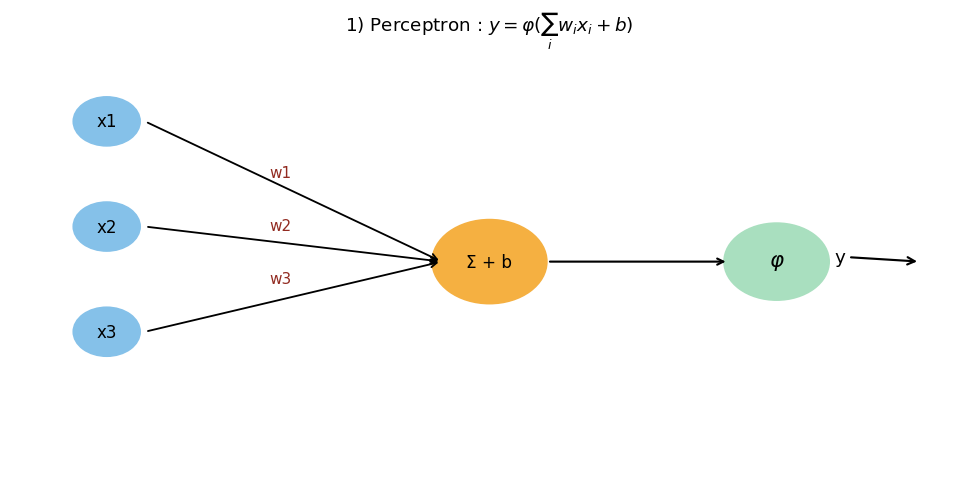

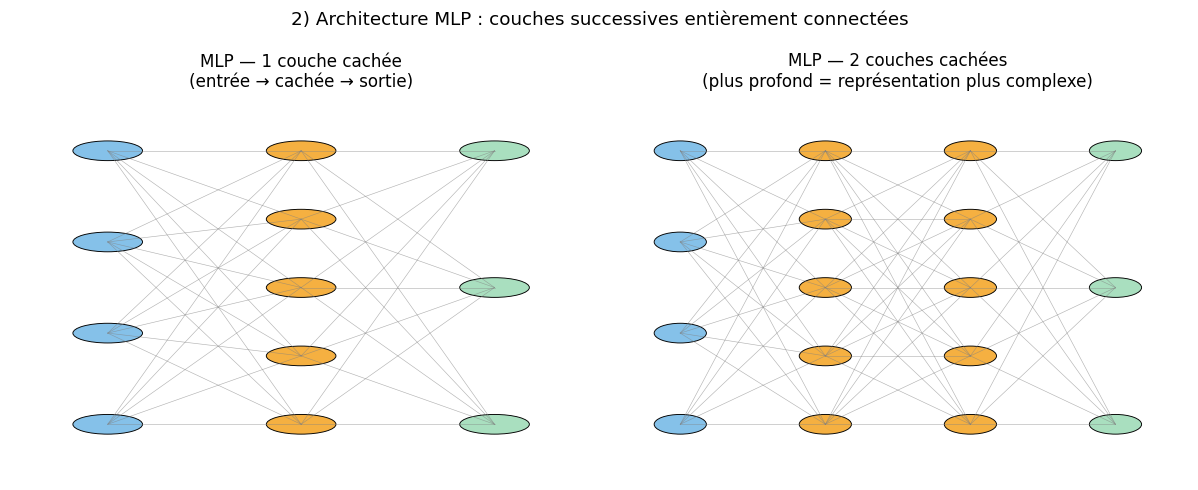

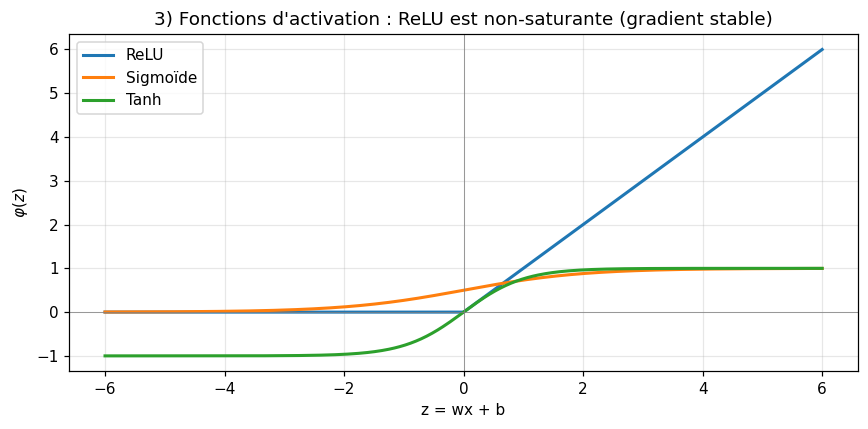

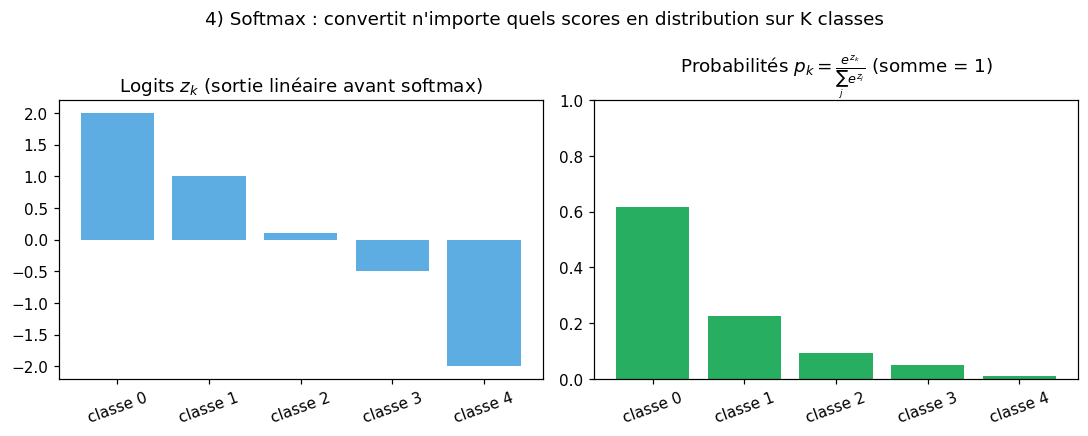

/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a

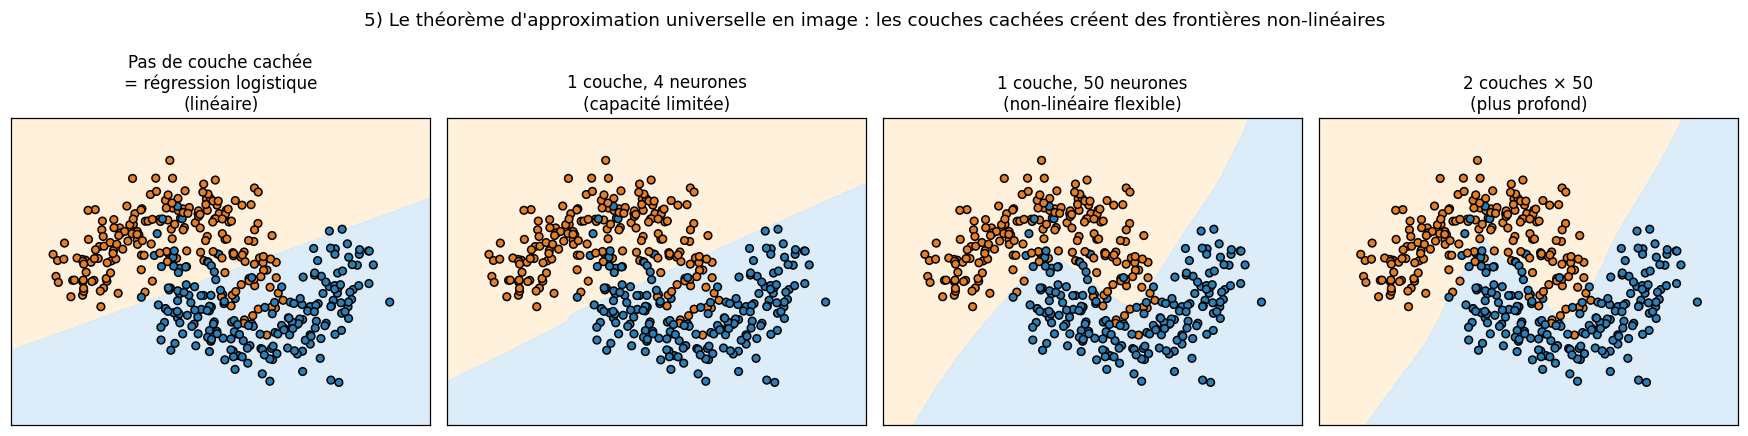

/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a

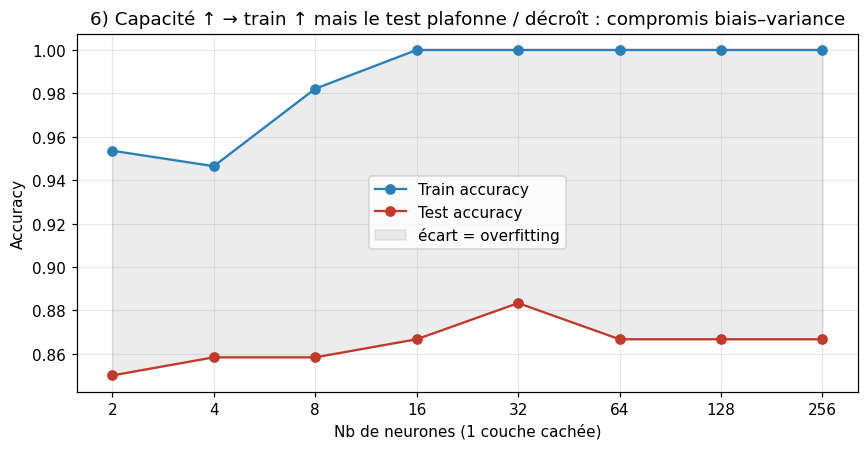

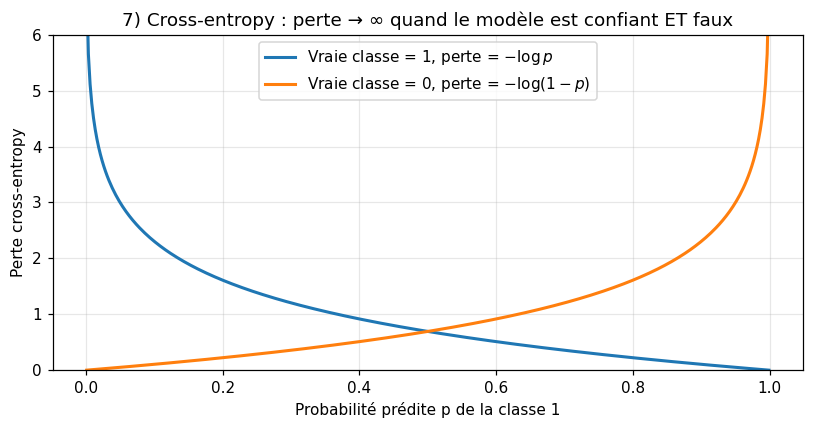

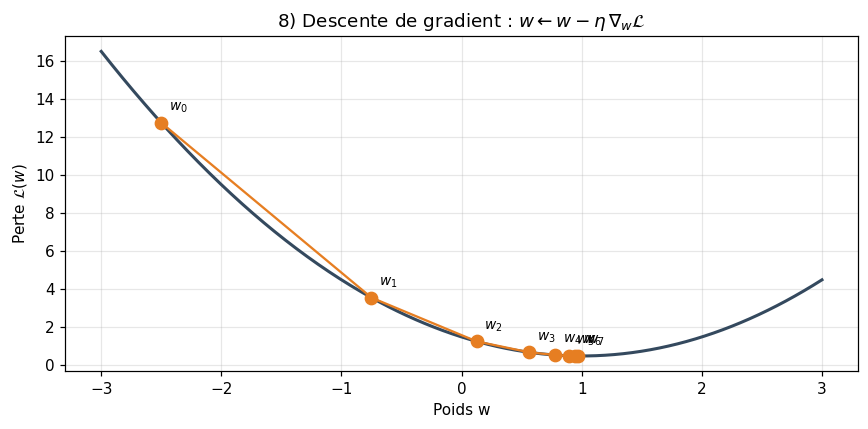

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams["figure.dpi"] = 110
cmap_bg = ListedColormap(["#FFEFD5", "#D6EAF8"])
cmap_pt = ListedColormap(["#E67E22", "#2980B9"])


def plot_decision(ax, clf, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.85)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pt, edgecolors="k", s=25)
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])


# =====================================================================
# 1) Le perceptron : entrées pondérées + activation
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")
inputs = ["x1", "x2", "x3"]
weights = ["w1", "w2", "w3"]
for i, name in enumerate(inputs):
    y0 = 5 - i * 1.5
    ax.add_patch(Circle((1, y0), 0.35, color="#85C1E9"))
    ax.text(1, y0, name, ha="center", va="center", fontsize=11)
    ax.annotate("", xy=(4.5, 3), xytext=(1.4, y0),
                arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.text(2.7, (y0 + 3) / 2 + 0.2, weights[i], fontsize=10, color="#922B21")
ax.add_patch(Circle((5, 3), 0.6, color="#F5B041"))
ax.text(5, 3, r"Σ + b", ha="center", va="center", fontsize=11)
ax.annotate("", xy=(7.5, 3), xytext=(5.6, 3),
            arrowprops=dict(arrowstyle="->", lw=1.4))
ax.add_patch(Circle((8, 3), 0.55, color="#A9DFBF"))
ax.text(8, 3, r"$\varphi$", ha="center", va="center", fontsize=14)
ax.annotate("y", xy=(9.5, 3), xytext=(8.6, 3),
            arrowprops=dict(arrowstyle="->", lw=1.4), fontsize=12)
ax.set_title("1) Perceptron : $y = \\varphi(\\sum_i w_i x_i + b)$")
plt.tight_layout(); plt.show()


# =====================================================================
# 2) Architecture MLP (une couche cachée vs deux couches)
# =====================================================================
def draw_mlp(ax, layers, title):
    ax.set_xlim(-0.5, len(layers) - 0.5); ax.set_ylim(-1, max(layers) + 1)
    ax.axis("off"); ax.set_title(title, fontsize=11)
    positions = []
    for li, n in enumerate(layers):
        ys = np.linspace(0, max(layers), n)
        positions.append([(li, y) for y in ys])
    for li in range(len(layers) - 1):
        for (x1, y1) in positions[li]:
            for (x2, y2) in positions[li + 1]:
                ax.plot([x1, x2], [y1, y2], color="grey", lw=0.4, alpha=0.6)
    colors = ["#85C1E9", "#F5B041", "#F5B041", "#A9DFBF"]
    for li, layer in enumerate(positions):
        c = colors[0] if li == 0 else (colors[-1] if li == len(layers) - 1 else "#F5B041")
        for (x, y) in layer:
            ax.add_patch(Circle((x, y), 0.18, color=c, ec="black", lw=0.6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
draw_mlp(axes[0], [4, 5, 3], "MLP — 1 couche cachée\n(entrée → cachée → sortie)")
draw_mlp(axes[1], [4, 5, 5, 3], "MLP — 2 couches cachées\n(plus profond = représentation plus complexe)")
plt.suptitle("2) Architecture MLP : couches successives entièrement connectées")
plt.tight_layout(); plt.show()


# =====================================================================
# 3) Fonctions d'activation
# =====================================================================
z = np.linspace(-6, 6, 400)
relu = np.maximum(0, z)
sig = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, relu, label="ReLU", lw=2)
ax.plot(z, sig, label="Sigmoïde", lw=2)
ax.plot(z, tanh, label="Tanh", lw=2)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("z = wx + b"); ax.set_ylabel(r"$\varphi(z)$")
ax.set_title("3) Fonctions d'activation : ReLU est non-saturante (gradient stable)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


# =====================================================================
# 4) Softmax : transforme des logits en distribution de probabilité
# =====================================================================
logits = np.array([2.0, 1.0, 0.1, -0.5, -2.0])
exps = np.exp(logits - logits.max())
probs = exps / exps.sum()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(len(logits)), logits, color="#5DADE2")
axes[0].set_title("Logits $z_k$ (sortie linéaire avant softmax)")
axes[0].set_xticks(range(len(logits)))
axes[0].set_xticklabels([f"classe {i}" for i in range(len(logits))], rotation=20)
axes[1].bar(range(len(probs)), probs, color="#27AE60")
axes[1].set_title("Probabilités $p_k = \\frac{e^{z_k}}{\\sum_j e^{z_j}}$ (somme = 1)")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(range(len(probs)))
axes[1].set_xticklabels([f"classe {i}" for i in range(len(probs))], rotation=20)
plt.suptitle("4) Softmax : convertit n'importe quels scores en distribution sur K classes")
plt.tight_layout(); plt.show()


# =====================================================================
# 5) Frontières de décision : régression logistique vs MLP non-linéaires
# =====================================================================
X, y = make_moons(n_samples=400, noise=0.25, random_state=0)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [
    ((), "Pas de couche cachée\n= régression logistique\n(linéaire)"),
    ((4,), "1 couche, 4 neurones\n(capacité limitée)"),
    ((50,), "1 couche, 50 neurones\n(non-linéaire flexible)"),
    ((50, 50), "2 couches × 50\n(plus profond)"),
]
for ax, (sizes, title) in zip(axes, configs):
    if len(sizes) == 0:
        from sklearn.linear_model import LogisticRegression
        clf = LogisticRegression().fit(X, y)
    else:
        clf = MLPClassifier(hidden_layer_sizes=sizes, max_iter=2000,
                            random_state=0).fit(X, y)
    plot_decision(ax, clf, X, y, title)
plt.suptitle("5) Le théorème d'approximation universelle en image : "
             "les couches cachées créent des frontières non-linéaires")
plt.tight_layout(); plt.show()


# =====================================================================
# 6) Capacité du réseau : underfit ↔ overfit (train vs test accuracy)
# =====================================================================
X, y = make_classification(n_samples=400, n_features=20, n_informative=8,
                           n_redundant=2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)
sizes = [(2,), (4,), (8,), (16,), (32,), (64,), (128,), (256,)]
labels = [str(s[0]) for s in sizes]
tr_acc, te_acc = [], []
for s in sizes:
    clf = MLPClassifier(hidden_layer_sizes=s, max_iter=2000,
                        random_state=0).fit(X_tr, y_tr)
    tr_acc.append(accuracy_score(y_tr, clf.predict(X_tr)))
    te_acc.append(accuracy_score(y_te, clf.predict(X_te)))
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(labels, tr_acc, "-o", label="Train accuracy", color="#2980B9")
ax.plot(labels, te_acc, "-o", label="Test accuracy",  color="#C0392B")
ax.set_xlabel("Nb de neurones (1 couche cachée)")
ax.set_ylabel("Accuracy")
ax.fill_between(labels, tr_acc, te_acc, alpha=0.15, color="grey",
                label="écart = overfitting")
ax.set_title("6) Capacité ↑ → train ↑ mais le test plafonne / décroît : compromis biais–variance")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


# =====================================================================
# 7) Cross-entropy : pénalise fortement les prédictions confiantes mais fausses
# =====================================================================
p = np.linspace(0.001, 0.999, 400)
loss_true_1 = -np.log(p)
loss_true_0 = -np.log(1 - p)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(p, loss_true_1, label="Vraie classe = 1, perte = $-\\log p$", lw=2)
ax.plot(p, loss_true_0, label="Vraie classe = 0, perte = $-\\log(1-p)$", lw=2)
ax.set_xlabel("Probabilité prédite p de la classe 1")
ax.set_ylabel("Perte cross-entropy")
ax.set_title("7) Cross-entropy : perte → ∞ quand le modèle est confiant ET faux")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 6)
plt.tight_layout(); plt.show()


# =====================================================================
# 8) Descente de gradient : intuition 1D
# =====================================================================
w = np.linspace(-3, 3, 400)
L = (w - 1) ** 2 + 0.5
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(w, L, color="#34495E", lw=2)
# Path of gradient descent
wt = -2.5
points = [wt]
for _ in range(7):
    grad = 2 * (wt - 1)
    wt = wt - 0.25 * grad
    points.append(wt)
points = np.array(points)
ax.plot(points, (points - 1) ** 2 + 0.5, "o-", color="#E67E22", ms=8)
for i, pt in enumerate(points):
    ax.annotate(f"$w_{i}$", (pt, (pt - 1) ** 2 + 0.5),
                textcoords="offset points", xytext=(5, 8), fontsize=9)
ax.set_xlabel("Poids w"); ax.set_ylabel("Perte $\\mathcal{L}(w)$")
ax.set_title("8) Descente de gradient : $w \\leftarrow w - \\eta\\, \\nabla_w \\mathcal{L}$")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
